## **Setup de librerías**

In [2]:
!pip install -q eva-decord==0.6.1
!pip install -q --no-deps lightning==2.4.0 torchmetrics==1.4.0
!pip install -q moviepy==1.0.3
!pip install -q av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 104.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 9.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 24.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 47.7 MB/s eta 0:00:00:00:0100:01


In [3]:
import os, glob, random, time, csv, math, json
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import lightning as L
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

import torchvision
from decord import VideoReader, cpu, gpu
import decord
decord.bridge.set_bridge('torch')

# Reproducibilidad básica
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# **Setup de hiperparámetros**

In [4]:
DATA_DIR = "/kaggle/input/crimeucfdataset/Anomaly_Dataset/Anomaly_Videos"

# Diccionario clase -> carpeta
# TODO: include robbery 
CLASS_PATHS = {
    "Normal":   Path(DATA_DIR, "Normal-Videos-Part-1"),
    "Abuse":    Path(DATA_DIR, "Anomaly-Videos-Part-1", "Abuse"),
    "Fighting": Path(DATA_DIR, "Anomaly-Videos-Part-2", "Fighting"),
}
CLASSES = list(CLASS_PATHS.keys())
NUM_CLASSES = len(CLASSES)

# Hiperparametros -----------------------------------------------
IMG_SIZE  = 112           # r3d_18 esta preentrenado a 112x112
CLIP_LEN  = 16            # frames por clip
FPS_READ  = None          # (opcional) para fijar fps, dejar None para muestreo uniforme por índice
HOP_TRAIN = CLIP_LEN//2   # salto entre clips en train (si uso multi-samples)
HOP_VAL   = CLIP_LEN//2

# clips aleatorios por video en cada epoch
TRAIN_SAMPLES_PER_VIDEO = 32 #24  
VAL_SAMPLES_PER_VIDEO   = 20 #10 


BATCH_SIZE  = 4 #2
NUM_WORKERS = 4
MAX_EPOCHS  = 15
LR = 2e-4
WD = 0.01
RATE = 2 # muestreo temporal cada 2 frames

# Normalizacion Kinetics para torchvision video models
KINETICS_MEAN = torch.tensor([0.43216, 0.394666, 0.37645]).view(3,1,1,1)
KINETICS_STD  = torch.tensor([0.22803, 0.22145, 0.216989]).view(3,1,1,1)

print("Clases:", CLASSES)

Clases: ['Normal', 'Abuse', 'Fighting']


# **PREPROCESAMIENTO DE DATOS**

## **Separacion de datos de entrenamiento y validacion**

In [5]:
def list_videos_from_dict(class_paths):
    items = []
    for ci, cname in enumerate(class_paths.keys()):
        base = class_paths[cname]
        mp4s = sorted(glob.glob(str(base / "*.mp4")))
        avis = sorted(glob.glob(str(base / "*.avi")))
        files = mp4s + avis
        items += [(f, ci) for f in files]
    random.shuffle(items)
    return items

all_items = list_videos_from_dict(CLASS_PATHS)
print("Total videos:", len(all_items))

# Split estratificado 80/20 a nivel video
per_class = {i: [] for i in range(NUM_CLASSES)}
for p, ci in all_items:
    per_class[ci].append(p)

train_items, val_items = [], []
for ci, vids in per_class.items():
    k = max(1, int(0.2 * len(vids)))
    val_items += [(p, ci) for p in vids[:k]]
    train_items += [(p, ci) for p in vids[k:]]
random.shuffle(train_items); random.shuffle(val_items)

# TODO: class balancing con data augmentation
print("Train:", len(train_items), "Val:", len(val_items))
print("Train por clase:", {CLASSES[i]: sum(1 for _,ci in train_items if ci==i) for i in range(NUM_CLASSES)})
print("Val   por clase:", {CLASSES[i]: sum(1 for _,ci in val_items   if ci==i) for i in range(NUM_CLASSES)})

labels = [ci for _, ci in train_items]
print("Distribución de clases en train:", {CLASSES[i]: labels.count(i) for i in range(NUM_CLASSES)})

# Pesos de clase (inverso-proporcional simple)
counts = np.array([len(per_class[i]) for i in range(NUM_CLASSES)], dtype=float)
cls_weights_np = counts.sum() / np.maximum(counts, 1.0)
_class_weights = torch.tensor(cls_weights_np, dtype=torch.float32)
print("Class weights:", _class_weights.tolist())

Total videos: 250
Train: 200 Val: 50
Train por clase: {'Normal': 120, 'Abuse': 40, 'Fighting': 40}
Val   por clase: {'Normal': 30, 'Abuse': 10, 'Fighting': 10}
Distribución de clases en train: {'Normal': 120, 'Abuse': 40, 'Fighting': 40}
Class weights: [1.6666666269302368, 5.0, 5.0]


## **Conversion de dataset a tensores** ##

In [6]:
class VideoClipDataset(Dataset):
    """
    Devuelve (C,T,H,W) en float [0,1].
    Para eficiencia, toma 'samples_per_video' clips aleatorios por epoch en train,
    y clips centrados/espaciados en val.
    """
    def __init__(self, items, samples_per_video=1, clip_len=16, img_size=112, train=True):
        self.items = items
        self.samples_per_video = samples_per_video
        self.clip_len = clip_len
        self.img_size = img_size
        self.train = train

        # expand para repetir videos por epoch y muestrear múltiples clips
        self.expanded = []
        for p, ci in self.items:
            for _ in range(samples_per_video):
                self.expanded.append((p, ci))

    def __len__(self):
        return len(self.expanded)

    def _choose_indices(self, T):
        if T <= self.clip_len:
            idxs = list(range(T)) + [T-1] * (self.clip_len - T)
            return idxs
        if self.train:
            start = random.randint(0, T - self.clip_len)
        else:
            start = (T - self.clip_len) // 2
        return list(range(start, start + self.clip_len * RATE, RATE))[:self.clip_len]

    def __getitem__(self, idx):
        path, label = self.expanded[idx]
        try:
            vr = VideoReader(path, ctx=cpu(0))
            T = len(vr)
            idxs = self._choose_indices(T)
            frames = vr.get_batch(idxs)                 # (T,H,W,3) uint8
            frames = frames.permute(3,0,1,2).float()    # (C,T,H,W) en [0,255]
            frames = frames/255.0
        except Exception as e:
            # fallback
            frames = torch.zeros(3, self.clip_len, 128, 128)

        # resize a IMG_SIZE
        frames = F.interpolate(frames, size=(self.img_size, self.img_size),
                               mode="bilinear", align_corners=False)
        return frames, label

# Instancias
train_ds = VideoClipDataset(train_items, TRAIN_SAMPLES_PER_VIDEO, CLIP_LEN, IMG_SIZE, train=True)
val_ds   = VideoClipDataset(val_items,   VAL_SAMPLES_PER_VIDEO,   CLIP_LEN, IMG_SIZE, train=False)

# Collate con normalización Kinetics
def collate_and_normalize(batch):
    xs, ys = zip(*batch)                 # cada x: (C,T,H,W) en [0,1]
    x = torch.stack(xs, 0)               # (B,C,T,H,W)
    y = torch.as_tensor(ys, dtype=torch.long)
    x = (x - KINETICS_MEAN) / KINETICS_STD
    return x, y

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin,
                          collate_fn=collate_and_normalize)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin,
                          collate_fn=collate_and_normalize)

# sanity check
print("Total muestras en train_ds:", len(train_ds))
print("Total batches por epoch:", len(train_loader))

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape, "labels:", yb[:8].tolist())
xb, yb = next(iter(train_loader))
print("Primer batch shape:", xb.shape)
print("Primer batch labels:", yb.tolist())
print("Clases presentes en primer batch:", set(yb.tolist()))

Total muestras en train_ds: 6400
Total batches por epoch: 1600
Batch shape: torch.Size([4, 3, 16, 112, 112]) labels: [1, 2, 2, 2]
Primer batch shape: torch.Size([4, 3, 16, 112, 112])
Primer batch labels: [0, 0, 0, 0]
Clases presentes en primer batch: {0}


# **ENTRENAMIENTO** #

In [7]:
# === Utils: Confusion Matrix (estilo legible: Blues + TP y FN/FP  ===
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix",
                          cmap="Blues", savepath=None):
    cm = np.array(cm, dtype=float)
    n = cm.shape[0]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(np.arange(n), labels=class_names)
    ax.set_yticks(np.arange(n), labels=class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    # anotaciones (negro/blanco según contraste)
    for i in range(n):
        for j in range(n):
            v = cm[i, j]
            main = f"{int(round(v))}"
            color_text = "black" if cm[i, j] < cm.max()/2 else "white"
            ax.text(j, i, f"{main}", ha="center", va="center",
                    fontsize=9, color=color_text, fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=220, bbox_inches="tight")
    plt.close(fig)  # importante si lo llamo en cada epoch

In [8]:
# === LitVid (LightningModule) — versión combinada: trazabilidad + smoothing + warmup+cosine + ConfusionMatrix ===
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from torchmetrics.classification import Accuracy, F1Score, MulticlassConfusionMatrix
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR
import numpy as np

class LitVid(L.LightningModule):
    def __init__(self, model, lr=2e-4, wd=0.05, class_weights=None, label_smoothing=0.05, class_names=None):
        super().__init__()
        # Guarda hiperparámetros (útil para reproducibilidad); no guardamos el modelo completo aquí
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        self.lr = float(lr)
        self.wd = float(wd)
        self.label_smoothing = float(label_smoothing)
        self.class_names = class_names
        assert len(self.class_names) == int(NUM_CLASSES) #"len(class_names) debe coincidir con num_classes"

        # Pesos de clase por defecto: vector de unos si no se pasan explícitamente
        if class_weights is None:
            cw = torch.ones(int(NUM_CLASSES), dtype=torch.float32)
        else:
            cw = class_weights.float()
        # Registrar como buffer para que se muevan al device correcto automáticamente
        self.register_buffer("class_weights", cw, persistent=True)

        # Métricas
        self.train_acc = Accuracy(task="multiclass", num_classes=int(NUM_CLASSES))
        self.val_acc   = Accuracy(task="multiclass", num_classes=int(NUM_CLASSES))
        self.val_f1    = F1Score(task="multiclass", num_classes=int(NUM_CLASSES), average="macro")

        # === Matriz de Confusión (validación) ===
        # TorchMetrics se encarga del sync en DDP al hacer compute()
        self.val_cm = MulticlassConfusionMatrix(num_classes=int(NUM_CLASSES))

        # Carpeta de salida para imágenes de CM
        self.cm_dir = "CONF_MATRICES"

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        x, y = batch  # videos, labels
        logits = self(x)
        loss = F.cross_entropy(
            logits, y,
            weight=self.class_weights,
            label_smoothing=self.label_smoothing
        )
        preds = logits.argmax(dim=1)
        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._step(batch)
        self.train_acc.update(preds, y)
        # Log por epoch (alineado con callbacks que escriben CSV por época)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc",  self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.train_acc.reset()

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._step(batch)
        self.val_acc.update(preds, y)
        self.val_f1.update(preds, y)

        # === Actualiza ConfusionMatrix con las predicciones de este batch ===
        self.val_cm.update(preds, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def on_validation_epoch_end(self):
        # Calcula y loguea métricas de validación
        val_acc = self.val_acc.compute()
        val_f1  = self.val_f1.compute()
        self.log("val_acc", val_acc, on_epoch=True, prog_bar=True)
        self.log("val_f1",  val_f1,  on_epoch=True, prog_bar=True)

        # ---- PRINTS por epoch (train y val) ----
        def _tofloat(x):
            try:
                return float(x)
            except Exception:
                try:
                    return float(x.item())
                except Exception:
                    return float("nan")

        t_loss = _tofloat(self.trainer.callback_metrics.get("train_loss", float("nan")))
        v_loss = _tofloat(self.trainer.callback_metrics.get("val_loss", float("nan")))
        t_acc  = _tofloat(self.trainer.callback_metrics.get("train_acc", float("nan")))
        v_acc  = _tofloat(val_acc)
        v_f1   = _tofloat(val_f1)
        epoch_idx = int(self.trainer.current_epoch) if hasattr(self.trainer, "current_epoch") else -1

        print(f"[Epoch {epoch_idx}] train_loss={t_loss:.4f} | train_acc={t_acc:.4f} | val_loss={v_loss:.4f} | val_acc={v_acc:.4f} | val_f1={v_f1:.4f}")

        # === Compute & guardar matriz de confusion ===
        try:
            cm = self.val_cm.compute().detach().cpu().numpy()
            self.val_cm.reset()
            os.makedirs(self.cm_dir, exist_ok=True)
            epoch_idx = int(self.trainer.current_epoch) if hasattr(self.trainer, "current_epoch") else -1
            # Rutas consistentes
            png_raw  = os.path.join(self.cm_dir, f"confmatrix_epoch{epoch_idx:03d}_r3d18_exp1.png")
            # Conteos
            plot_confusion_matrix(
                cm, self.class_names,
                title=f"Confusion Matrix - epoch {epoch_idx} - R3D18",
                savepath=png_raw
            )
        except Exception as e:
            print(f"[WARN] No se pudo generar/guardar la confusion matrix: {e}")

        # Reset métricas de validación
        self.val_acc.reset()
        self.val_f1.reset()

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.wd)

        # Calcular total_steps de forma robusta
        total_steps = None
        est = getattr(self.trainer, "estimated_stepping_batches", None)
        if est is not None:
            try:
                total_steps = int(est)
            except Exception:
                total_steps = None
        if total_steps is None:
            # Fallback a variables globales si existen (compatibilidad con el notebook)
            try:
                total_steps = int(MAX_EPOCHS * len(train_loader))  # noqa: F821
            except Exception:
                total_steps = 1000  # fallback seguro

        warmup_steps = max(1, int(0.1 * total_steps))
        cosine_steps = max(1, total_steps - warmup_steps)

        sch1 = LinearLR(opt, start_factor=0.1, total_iters=warmup_steps)
        sch2 = CosineAnnealingLR(opt, T_max=cosine_steps)

        sched = SequentialLR(opt, schedulers=[sch1, sch2], milestones=[warmup_steps])

        return {
            "optimizer": opt,
            "lr_scheduler": {
                "scheduler": sched,
                "interval": "step",   # Importante: scheduler por *pasos*
            },
        }

In [12]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.callbacks import Callback

model = torchvision.models.video.r3d_18(weights="KINETICS400_V1")
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

'''
class CSVLoggerCallback(Callback):
    def __init__(self, filename="training_metrics.csv"):
        super().__init__()
        self.filename = filename
        self.header_written = False

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        row = [
            trainer.current_epoch,
            float(metrics.get("train_loss", float("nan"))),
            float(metrics.get("train_acc", float("nan"))),
            float(metrics.get("val_loss", float("nan"))),
            float(metrics.get("val_acc", float("nan"))),
            float(metrics.get("val_f1", float("nan")))
        ]
        with open(self.filename, "a", newline="") as f:
            import csv
            writer = csv.writer(f)
            if not self.header_written:
                writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "val_f1"])
                self.header_written = True
            writer.writerow(row)

lit = LitVid(model, lr=LR, wd=WD, class_weights=_class_weights, class_names=CLASSES)

precision = "bf16-mixed" if torch.cuda.is_available() else 32

early_stop = EarlyStopping(
    monitor="val_f1",   # o "val_loss"
    mode="max",         # "min" si vigilo val_loss
    patience=7,         # nº de épocas sin mejora antes de parar
    min_delta=1e-3,     # mejora mínima para contar como “mejor”
    check_on_train_epoch_end=False
)

ckpt_saver = ModelCheckpoint(
    dirpath="CHECKPOINTS",
    monitor="val_f1",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename="{epoch:02d}-valf1{val_f1:.4f}",
)

callbacks_list = [CSVLoggerCallback(), early_stop, ckpt_saver]

trainer = L.Trainer(
    accelerator="auto",
    devices=1,
    precision=precision,
    max_epochs=MAX_EPOCHS,
    callbacks=callbacks_list,
)

trainer.fit(lit, train_loader, val_loader) # ESTE ENTRENAMIENTO DURA 4 HORAS
print("BEST CHECKPOINT (highest F1):", ckpt_saver.best_model_path, ckpt_saver.best_model_score)
'''

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth
100%|██████████| 127M/127M [00:01<00:00, 128MB/s]  


'\nclass CSVLoggerCallback(Callback):\n    def __init__(self, filename="training_metrics.csv"):\n        super().__init__()\n        self.filename = filename\n        self.header_written = False\n\n    def on_train_epoch_end(self, trainer, pl_module):\n        metrics = trainer.callback_metrics\n        row = [\n            trainer.current_epoch,\n            float(metrics.get("train_loss", float("nan"))),\n            float(metrics.get("train_acc", float("nan"))),\n            float(metrics.get("val_loss", float("nan"))),\n            float(metrics.get("val_acc", float("nan"))),\n            float(metrics.get("val_f1", float("nan")))\n        ]\n        with open(self.filename, "a", newline="") as f:\n            import csv\n            writer = csv.writer(f)\n            if not self.header_written:\n                writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "val_f1"])\n                self.header_written = True\n            writer.writerow(row)\n\nlit

# **INFERENCIA** #

In [13]:
# === Inferencia por vídeo (N>1 clips) + predicción por mayoría/promedio
# ================================

@torch.no_grad()
def score_video_logits_r3d(path, clip_len=CLIP_LEN, hop=CLIP_LEN//2):
    vr = VideoReader(path, ctx=cpu(0))
    T = len(vr)
    idxs_list=[]; start=0
    while start + clip_len <= T:
        idxs_list.append(list(range(start, start + clip_len)))
        start += hop
    if not idxs_list:
        idxs_list = [list(range(0, min(clip_len, T)))]

    model.eval().to(DEVICE)
    logits_all=[]
    for idxs in idxs_list:
        frames = vr.get_batch(idxs).permute(3,0,1,2).float()/255.0   # (C,T,H,W)
        frames = F.interpolate(frames, size=(IMG_SIZE,IMG_SIZE), mode="bilinear", align_corners=False)
        frames = (frames - KINETICS_MEAN) / KINETICS_STD
        out = model(frames.unsqueeze(0).to(DEVICE))                  # (1,C,T,H,W)
        logits_all.append(out.squeeze(0).cpu())
    return torch.stack(logits_all,0).mean(0)                         # (NUM_CLASSES,)

def predict_video_label_r3d(path):
    logits = score_video_logits_r3d(path, clip_len=CLIP_LEN, hop=CLIP_LEN//2)
    prob = torch.softmax(logits, dim=0)
    cid = int(torch.argmax(prob).item())
    return CLASSES[cid], [float(p) for p in prob]

# Demo en 3 vídeos del split de validación
for p,ci in val_items[:3]:
    lab, prob = predict_video_label_r3d(p)
    print(Path(p).name, "->", lab, [round(x,4) for x in prob])


Abuse048_x264.mp4 -> Fighting [0.289, 0.2222, 0.4888]
Normal_Videos_868_x264.mp4 -> Abuse [0.288, 0.4392, 0.2728]
Abuse027_x264.mp4 -> Fighting [0.3559, 0.2829, 0.3612]


In [14]:
# ================================
# ========== CELL 8 ==============
# === Localización temporal ligera (segmentos con score alto)
# ================================
import numpy as np
import torch
import torch.nn.functional as F
from decord import VideoReader, cpu

# ---- 1) Cargar el MEJOR checkpoint (Lightning) una vez ----
#    Si sigues en la misma sesión del fit: usa ckpt_cb.best_model_path
#    Si no: pon la ruta manual del .ckpt que guardaste como "mejor"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    best_ckpt = ckpt_cb.best_model_path  # si vienes del fit en la misma sesión
    assert isinstance(best_ckpt, str) and best_ckpt.endswith(".ckpt") and len(best_ckpt) > 5
except Exception:
    # en caso de ya no estar en la misma sesion
    best_ckpt = "/kaggle/working/CHECKPOINTS/epoch=00-valf1val_f1=0.6504.ckpt"
    #epoch=04-valf1val_f1=0.6137.ckpt

# Carga el LightningModule con los mismos args que usaste al entrenar
# (ajusta estos kwargs a tu LitVid)
mdl = LitVid.load_from_checkpoint(
    best_ckpt,
    model=model,                 # tu backbone inicializado con la misma arquitectura
    class_weights=_class_weights, # si aplica
    label_smoothing=0.05,         # si aplica
    class_names=CLASSES       
).eval().to(device)

print("Usando mejor checkpoint:", best_ckpt)


# ---- 2) Función de localización temporal usando SIEMPRE `mdl` ----
@torch.no_grad()
def temporal_localization_r3d(path, th=0.6, clip_len=CLIP_LEN, hop=CLIP_LEN//2, min_seg_clips=2):
    vr = VideoReader(path, ctx=cpu(0))
    T = len(vr)
    idxs_list=[]; start=0
    while start + clip_len <= T:
        idxs_list.append(list(range(start, start+clip_len)))
        start += hop
    if not idxs_list:  # videos muy cortos
        idxs_list=[list(range(0, min(clip_len, T)))]

    # --- inferencia con el mejor checkpoint cargado (mdl) ---
    probs=[]
    for idxs in idxs_list:
        # [T,H,W,C] -> [C,T,H,W]
        frames = vr.get_batch(idxs).permute(3,0,1,2).float() / 255.0  # C,T,H,W

        # (1) Añadir batch: [1,C,T,H,W]
        frames = frames.unsqueeze(0)

        # (2) Redimensionar SOLO espacial, manteniendo T actual (resize 3D)
        Tcur = frames.shape[2]
        frames = F.interpolate(
            frames, size=(Tcur, IMG_SIZE, IMG_SIZE),  # (T, H, W) — Tcur sin cambios
            mode="trilinear", align_corners=False
        )

        # (3) Normalización canal a canal
        frames = (frames - KINETICS_MEAN.view(1,3,1,1,1)) / KINETICS_STD.view(1,3,1,1,1)

        # (4) Forward
        logits = mdl(frames.to(device)).squeeze(0).cpu()  # (C,)
        prob   = torch.softmax(logits, dim=0).numpy()
        probs.append(prob)

    probs = np.stack(probs,0)  # [Nclips, C]

    # --- construcción de segmentos por clase (ignorando 'Normal') ---
    segs=[]
    for c in range(NUM_CLASSES):
        if CLASSES[c] == "Normal":
            continue
        mask = probs[:,c] >= th
        s=None; best=0.0
        for i,m in enumerate(mask):
            if m and s is None:
                s=i; best=probs[i,c]
            elif m:
                best=max(best, probs[i,c])
            elif s is not None:
                if i-s >= min_seg_clips:
                    segs.append((s, i, c, float(best)))
                s=None; best=0.0
        if s is not None and len(mask)-s >= min_seg_clips:
            segs.append((s, len(mask), c, float(best)))

    # convertir a segundos (aprox)
    fps = float(vr.get_avg_fps() or 25.0)
    out=[]
    for s,e,c,b in segs:
        t0 = s * (hop / fps)
        t1 = e * (hop / fps)
        out.append({"t0_sec": round(t0,2), "t1_sec": round(t1,2), "class": CLASSES[c], "score": round(b,3)})
    return out


Usando mejor checkpoint: /kaggle/working/CHECKPOINTS/epoch=00-valf1val_f1=0.6504.ckpt


## Comparacion de weights por capa

Cargando Lightning ckpt: /kaggle/working/CHECKPOINTS/epoch=00-valf1val_f1=0.6504.ckpt

Finetuned vs Pretrained (capas con mayor cambio)
------------------------------------------------
name                                                   numel    mean_abs     max_abs          l2  same_shape
stem.1.running_var                                        64    4.241602   46.770367   74.616760  True
stem.1.running_mean                                       64    0.253681    1.270578    3.244016  True
layer1.1.conv1.1.running_var                              64    0.230565    2.140482    3.812358  True
layer2.0.conv1.1.running_var                             128    0.165124    1.325010    2.822108  True
layer4.1.conv1.1.running_mean                            512    0.146734    0.637886    4.087331  True
layer4.1.conv1.1.running_var                             512    0.141033    0.492827    3.725082  True
layer3.0.conv1.1.running_mean                            256    0.137605    0.558911    

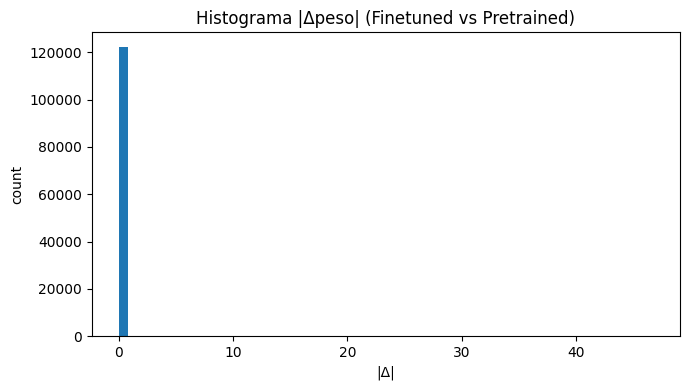


FC weight shape: (3, 512)
Primeros 5 pesos de la primera neurona: [-0.00985   0.003363 -0.004559  0.016897  0.007198]


In [19]:
# ==========================================
# === Comparador de pesos por capa (R3D18)
# ==========================================
import os, math, csv
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models.video import r3d_18, R3D_18_Weights

# ==== CONFIG ====
USE_LIGHTNING = True  # True: cargar mejor .ckpt; False: usar 'model' en memoria
BEST_CKPT = "/kaggle/working/CHECKPOINTS/epoch=00-valf1val_f1=0.6504.ckpt"      # si conoces la ruta ponla aquí; si no, se intenta ckpt_cb.best_model_path
COMPARE_BASELINE = True  # compara contra r3d_18(pretrained=True)
SAVE_CSV = True
CSV_PATH = "weight_diffs_by_layer.csv"
PLOT_HIST = True       # histograma global de difs absolutas (muestra)
HIST_SAMPLE = 500000   # cuántos valores muestrear para el histograma (para no explotar memoria)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==== Helpers (version corregida) ====
def _sd(model):  # state_dict en CPU
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}

def _is_float_tensor(t: torch.Tensor) -> bool:
    return t.is_floating_point() or t.is_complex()

def _compare_state_dicts(sd_a, sd_b, prefix_filter=None, skip_non_float=True, skip_mismatch=True):
    """
    Compara parámetros capa a capa entre dos state_dicts.
    - Convierte a float32 antes de calcular diferencias.
    - Opcionalmente ignora tensores no flotantes (num_batches_tracked, etc.) y/o capas con forma distinta.
    Devuelve:
      - rows: lista de dicts {name, numel, mean_abs, max_abs, l2, same_shape}
      - all_abs: vector numpy muestreado de |Δ| para histograma global
    """
    rows = []
    all_abs_chunks = []

    for name, wa in sd_a.items():
        if prefix_filter is not None and not name.startswith(prefix_filter):
            continue
        if name not in sd_b:
            continue

        wb = sd_b[name]

        # Omitir tensores no flotantes si se desea
        if skip_non_float and (not _is_float_tensor(wa) or not _is_float_tensor(wb)):
            # Registrar como no comparable pero reportable
            rows.append({
                "name": name, "numel": int(wa.numel()),
                "mean_abs": float("nan"), "max_abs": float("nan"),
                "l2": float("nan"), "same_shape": (wa.shape == wb.shape)
            })
            continue

        same_shape = (wa.shape == wb.shape)
        if not same_shape:
            if skip_mismatch:
                rows.append({
                    "name": name, "numel": int(wa.numel()),
                    "mean_abs": float("nan"), "max_abs": float("nan"),
                    "l2": float("nan"), "same_shape": False
                })
                continue
            else:
                # Si no saltamos, hay que ajustar/broadcast, pero NO es recomendable.
                rows.append({
                    "name": name, "numel": int(wa.numel()),
                    "mean_abs": float("nan"), "max_abs": float("nan"),
                    "l2": float("nan"), "same_shape": False
                })
                continue

        # Convertir a float32 para evitar errores (Long/Int)
        wa = wa.to(torch.float32)
        wb = wb.to(torch.float32)

        diff = (wa - wb).reshape(-1)
        mad  = diff.abs()

        rows.append({
            "name": name,
            "numel": int(mad.numel()),
            "mean_abs": float(mad.mean().item()),
            "max_abs":  float(mad.max().item()),
            "l2":       float(torch.linalg.vector_norm(diff).item()),
            "same_shape": True
        })

        # Muestras para histograma global (submuestreo por tensor)
        if mad.numel() > 0:
            if mad.numel() <= 10000:
                all_abs_chunks.append(mad)
            else:
                idx = torch.randint(0, mad.numel(), (min(5000, mad.numel()),))
                all_abs_chunks.append(mad[idx])

    if len(all_abs_chunks):
        all_abs = torch.cat(all_abs_chunks, 0).cpu().numpy()
        # muestreo final si excede HIST_SAMPLE (usa tu constante)
        if 'HIST_SAMPLE' in globals() and all_abs.shape[0] > HIST_SAMPLE:
            sel = np.random.choice(all_abs.shape[0], size=HIST_SAMPLE, replace=False)
            all_abs = all_abs[sel]
    else:
        all_abs = np.array([])

    # Ordenar por mean_abs desc y luego l2
    rows.sort(key=lambda r: (-(r["mean_abs"] if not math.isnan(r["mean_abs"]) else -1),
                             -(r["l2"] if not math.isnan(r["l2"]) else -1)))
    return rows, all_abs

def _print_top(rows, k=15, title="Top capas por cambio (mean abs)"):
    print("\n" + title)
    print("-"*len(title))
    print(f"{'name':50s}  {'numel':>8s}  {'mean_abs':>10s}  {'max_abs':>10s}  {'l2':>10s}  same_shape")
    for r in rows[:k]:
        print(f"{r['name'][:50]:50s}  {r['numel']:8d}  {r['mean_abs']:10.6f}  {r['max_abs']:10.6f}  {r['l2']:10.6f}  {r['same_shape']}")

def _save_csv(rows, path):
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["name","numel","mean_abs","max_abs","l2","same_shape"])
        w.writeheader()
        for r in rows:
            w.writerow(r)
    print("CSV guardado ->", path)

# ==== 1) Construir 'mdl' (Lightning) o usar 'model' en memoria ====
if USE_LIGHTNING:
    if BEST_CKPT is None:
        BEST_CKPT = ckpt_cb.best_model_path if "ckpt_cb" in globals() and getattr(ckpt_cb, "best_model_path", "") else None
    assert BEST_CKPT and BEST_CKPT.endswith(".ckpt"), "No encontré ruta del mejor checkpoint (.ckpt). Asigna BEST_CKPT."
    print("Cargando Lightning ckpt:", BEST_CKPT)
    # IMPORTANTE: pasa los mismos kwargs que usaste al crear LitVid
    lit_loaded = LitVid.load_from_checkpoint(
        BEST_CKPT,
        model=model,                        # mismo backbone/arquitectura
        class_weights=_class_weights,        # si aplica
        label_smoothing=0.05,               # si aplica
        class_names=CLASSES                 # si usas nombres
    ).eval().to(DEVICE)
    mdl = lit_loaded.model  # comparamos pesos del backbone+head
else:
    assert "model" in globals(), "No hay variable 'model' en memoria."
    mdl = model.eval().to(DEVICE)

# ==== 2) State dicts a comparar ====
sd_finetuned = _sd(mdl)

# (B) Comparación contra el modelo PREENTRENADO original
if COMPARE_BASELINE:
    base = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)  # equivalente al warning
    rows_base, all_abs_base = _compare_state_dicts(sd_finetuned, _sd(base))
    _print_top(rows_base, title="Finetuned vs Pretrained (capas con mayor cambio)")
    if SAVE_CSV:
        _save_csv(rows_base, CSV_PATH)

    if PLOT_HIST and all_abs_base.size > 0:
        plt.figure(figsize=(7,4))
        plt.hist(all_abs_base, bins=60)
        plt.title("Histograma |Δpeso| (Finetuned vs Pretrained)")
        plt.xlabel("|Δ|"); plt.ylabel("count")
        plt.tight_layout()
        plt.show()

# ==== 3) Ejemplos de inspección puntual ====
# Ver algunos pesos de la última capa si existe:
if hasattr(mdl, "fc"):
    w = mdl.fc.weight.data.detach().cpu().numpy()
    print("\nFC weight shape:", w.shape)
    print("Primeros 5 pesos de la primera neurona:", np.round(w[0,:5], 6))
else:
    print("\n[Nota] El modelo no expone 'fc'; ajustela capa que quiera inspeccionar.")


# NEW FULL INFERENCE

In [25]:
# ================================
# ========== FULL VIDEO ==========
# === Anotación completa de un video de validación con el MEJOR checkpoint (Lightning)
# ================================
# Requisitos previos en el notebook:
# - Variables/objetos existentes: model, DEVICE, CLASSES, CLIP_LEN, IMG_SIZE, KINETICS_MEAN, KINETICS_STD
# - Librerías instaladas: moviepy, decord, PIL

from decord import VideoReader, cpu
from moviepy.editor import VideoFileClip, ImageClip, ColorClip, CompositeVideoClip
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import torch
import torch.nn.functional as F
import textwrap

# ---------- 0) Cargar el MEJOR checkpoint de Lightning UNA SOLA VEZ ----------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    best_ckpt = ckpt_cb.best_model_path  # si vienes del fit en la misma sesión
    assert isinstance(best_ckpt, str) and best_ckpt.endswith(".ckpt") and len(best_ckpt) > 5
except Exception:
    # <- EDITA esta ruta si estás fuera de la sesión del fit
    best_ckpt = "/kaggle/working/CHECKPOINTS/epoch=00-valf1val_f1=0.6504.ckpt"

# Carga el LightningModule con los mismos args que usaste al entrenar
# (ajusta kwargs según tu LitVid)
mdl = LitVid.load_from_checkpoint(
    best_ckpt,
    model=model,                 # backbone con la MISMA arquitectura
    class_weights=_class_weights, # si aplica
    label_smoothing=0.05,        # si aplica
    class_names=CLASSES
).eval().to(device)

print("Usando mejor checkpoint para FULL VIDEO:", best_ckpt)


# ---------- 1) Render de texto con PIL (sin ImageMagick) ----------

def _text_image_rgba(w, h, text, fontsize=34, fg=(255,255,255), bg=(0,0,0,0)):
    img = Image.new("RGBA", (w, h), bg)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", fontsize)
    except Exception:
        font = ImageFont.load_default()
    wrapped = textwrap.fill(text, width=max(10, int(w/18)))
    bbox = draw.multiline_textbbox((0,0), wrapped, font=font, align="center")
    tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
    x = max(0, (w - tw)//2)
    y = max(0, (h - th)//2)
    draw.multiline_text((x, y), wrapped, font=font, fill=fg+(255,), align="center", spacing=4)
    return img


# ---------- 2) Probabilidades por clip en todo el video (usa SIEMPRE `mdl`) ----------

@torch.no_grad()
def _clip_probs_r3d(video_path, clip_len, hop, img_size, mean, std, classes):
    vr = VideoReader(video_path, ctx=cpu(0))
    T = len(vr)
    if T == 0:
        return 25.0, np.zeros((0, len(classes))), 0

    # Ventanas de índices
    idxs_list = []
    start = 0
    while start + clip_len <= T:
        idxs_list.append(list(range(start, start + clip_len)))
        start += hop
    if not idxs_list:
        idxs_list = [list(range(0, min(clip_len, T)))]
    N = len(idxs_list)

    fps = float(vr.get_avg_fps() or 25.0)

    probs = []
    for idxs in idxs_list:
        # frames: [T, H, W, C] -> [C, T, H, W]
        frames = vr.get_batch(idxs).permute(3,0,1,2).float() / 255.0

        # [1, C, T, H, W] para interpolación 3D manteniendo T
        frames = frames.unsqueeze(0)
        Tcur = frames.shape[2]
        frames = F.interpolate(
            frames,
            size=(Tcur, img_size, img_size),  # (T,H,W) — mantenemos Tcur
            mode="trilinear",
            align_corners=False
        )

        # Normalización: broadcast a [1, C, T, H, W]
        frames = (frames - KINETICS_MEAN.view(1,3,1,1,1)) / KINETICS_STD.view(1,3,1,1,1)

        # Inferencia con el mejor checkpoint
        logits = mdl(frames.to(device)).squeeze(0).cpu()  # (C,)
        p = torch.softmax(logits, dim=0).numpy()
        probs.append(p)

    probs = np.stack(probs, 0)  # [N, C]
    return fps, probs, N


# ---------- 3) Fusionar clips contiguos con la misma etiqueta ----------

def _merge_label_spans(labels, scores, hop_seconds):
    spans = []
    if len(labels) == 0:
        return spans
    s = 0
    for i in range(1, len(labels) + 1):
        if i == len(labels) or labels[i] != labels[s]:
            t0 = s * hop_seconds
            t1 = i * hop_seconds
            best = float(np.max(scores[s:i])) if i > s else float(scores[s])
            spans.append((s, i, labels[s], best, t0, t1))
            s = i
    return spans


# ---------- 4) Anotación completa del video usando el mejor checkpoint ----------

def annotate_full_video_portable(video_path, out_path="exp1_annot_full.mp4",
                                 th_crime=0.60, band_height=60, fontsize=34,
                                 include_prob=True):
    """
    Anota todo el video con predicciones por tramo:
      - Si la mejor clase NO 'Normal' >= th_crime -> etiqueta esa clase.
      - En caso contrario -> etiqueta 'Normal' (si existe) o top-1 global.
    Devuelve la lista de spans: [{t0_sec, t1_sec, class, score}, ...]
    """
    # 1) Inferencia por clips solapados
    hop = CLIP_LEN // 2
    fps, probs, N = _clip_probs_r3d(video_path, CLIP_LEN, hop, IMG_SIZE, KINETICS_MEAN, KINETICS_STD, CLASSES)
    if N == 0:
        print("No se pudieron generar clips.")
        return []

    # 2) Etiquetado por clip
    try:
        normal_idx = CLASSES.index("Normal")
    except ValueError:
        normal_idx = None

    labels, top_scores = [], []
    for i in range(N):
        p = probs[i]
        if normal_idx is not None:
            # mejor clase no-Normal
            mask = np.ones(len(CLASSES), dtype=bool); mask[normal_idx] = False
            crime_idx_local = int(np.argmax(p[mask])) if mask.any() else int(np.argmax(p))
            crime_idx = crime_idx_local + 1 if (mask.any() and crime_idx_local >= normal_idx) else crime_idx_local
            crime_prob = float(p[crime_idx]) if mask.any() else float(np.max(p))
            lbl_idx = crime_idx if (mask.any() and crime_prob >= th_crime) else normal_idx
        else:
            # sin 'Normal': usar top-1
            lbl_idx = int(np.argmax(p))
        labels.append(lbl_idx)
        top_scores.append(float(p[lbl_idx]))

    # 3) Fusionar en spans legibles
    hop_seconds = hop / fps
    merged = _merge_label_spans(labels, top_scores, hop_seconds)

    # 4) Composición visual
    base = VideoFileClip(video_path).without_audio()  # sin audio para evitar ALSA
    W, H = base.w, base.h

    # Color por clase (gris para Normal)
    palette = [
        (128,128,128), (220, 20, 60), (255,140,0), (34,139,34), (30,144,255),
        (138,43,226), (205,92,92), (47,79,79), (70,130,180), (199,21,133)
    ]
    def color_for(idx):
        if normal_idx is not None and idx == normal_idx:
            return (80,80,80)
        return palette[idx % len(palette)]

    overlays = []
    for (_s, _e, lbl_idx, best_score, t0, t1) in merged:
        dur = max(0.05, t1 - t0)
        label = CLASSES[lbl_idx]
        txt = f"{label}" + (f" (p={best_score:.2f})" if include_prob else "")

        band = (ColorClip(size=(W, band_height), color=color_for(lbl_idx))
                .set_opacity(0.35)
                .set_position(("center", H - band_height))
                .set_start(t0).set_duration(dur))

        pil_img = _text_image_rgba(W, band_height, txt, fontsize=fontsize, fg=(255,255,255), bg=(0,0,0,0))
        np_img = np.array(pil_img).astype("uint8")
        txt_clip = (ImageClip(np_img, transparent=True)
                    .set_position(("center", H - band_height))
                    .set_start(t0).set_duration(dur))

        overlays += [band, txt_clip]

    comp = CompositeVideoClip([base, *overlays])
    comp.write_videofile(out_path, codec="libx264", audio=False, fps=base.fps,
                         verbose=False, logger=None)
    print("Guardado:", out_path)

    # 5) Devolver spans legibles
    spans = [{"t0_sec": round(t0,2), "t1_sec": round(t1,2),
              "class": CLASSES[lbl_idx], "score": round(best_score,3)}
             for (_s,_e,lbl_idx,best_score,t0,t1) in merged]
    return spans


# --- Ejemplo rápido (ajusta el índice según tu split de validación) ---
spans = annotate_full_video_portable(val_items[1][0], out_path="34th_exp1_annot_full.mp4", th_crime=0.65)
print(spans[:10])

Usando mejor checkpoint para FULL VIDEO: /kaggle/working/CHECKPOINTS/epoch=00-valf1val_f1=0.6504.ckpt
Guardado: 34th_exp1_annot_full.mp4
[{'t0_sec': 0.0, 't1_sec': 79.73, 'class': 'Fighting', 'score': 0.947}]


In [24]:
# ================================
# ========== FULL VIDEO ==========
# === Anotación completa de un video de validacion con predicciones del modelo (FIX interpolate)
# ================================
# Requisitos previos en el notebook:
# - Variables/objetos existentes: model, DEVICE, CLASSES, CLIP_LEN, IMG_SIZE, KINETICS_MEAN, KINETICS_STD
# - Librerías instaladas: moviepy, decord, PIL
#
# Uso:
# spans = annotate_full_video_portable(val_items[0][0], out_path="annot_full.mp4", th_crime=0.65)
# print(spans[:10])

from decord import VideoReader, cpu
from moviepy.editor import VideoFileClip, ImageClip, ColorClip, CompositeVideoClip
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import torch
import torch.nn.functional as F
import textwrap

# --- Render de texto con PIL (sin ImageMagick) ---
def _text_image_rgba(w, h, text, fontsize=34, fg=(255,255,255), bg=(0,0,0,0)):
    img = Image.new("RGBA", (w, h), bg)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", fontsize)
    except Exception:
        font = ImageFont.load_default()
    wrapped = textwrap.fill(text, width=max(10, int(w/18)))
    bbox = draw.multiline_textbbox((0,0), wrapped, font=font, align="center")
    tw, th = bbox[2]-bbox[0], bbox[3]-bbox[1]
    x = max(0, (w - tw)//2)
    y = max(0, (h - th)//2)
    draw.multiline_text((x, y), wrapped, font=font, fill=fg+(255,), align="center", spacing=4)
    return img

# --- Probabilidades por clip en todo el video ---
def _clip_probs_r3d(video_path, clip_len, hop, img_size, mean, std, classes):
    vr = VideoReader(video_path, ctx=cpu(0))
    T = len(vr)
    if T == 0:
        return 25.0, np.zeros((0, len(classes))), 0

    # Ventanas de índices
    idxs_list = []
    start = 0
    while start + clip_len <= T:
        idxs_list.append(list(range(start, start + clip_len)))
        start += hop
    if not idxs_list:
        idxs_list = [list(range(0, min(clip_len, T)))]
    N = len(idxs_list)

    fps = float(vr.get_avg_fps() or 25.0)

    model.eval().to(DEVICE)
    probs = []
    with torch.no_grad():
        for idxs in idxs_list:
            # frames: [T, H, W, C] -> [C, T, H, W]
            frames = vr.get_batch(idxs).permute(3,0,1,2).float() / 255.0
            # Añadir batch y redimensionar SOLO espacial (mantener T)
            frames = frames.unsqueeze(0)  # [1, C, T, H, W]
            Tcur, Hcur, Wcur = frames.shape[2], frames.shape[3], frames.shape[4]
            frames = F.interpolate(
                frames,
                size=(Tcur, img_size, img_size),  # (T, H, W)
                mode="trilinear",
                align_corners=False
            ).squeeze(0)  # [C, T, H, W]
            # Normalización
            frames = (frames - mean) / std
            # Inferencia
            logits = model(frames.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
            p = torch.softmax(logits, dim=0).numpy()
            probs.append(p)
    probs = np.stack(probs, 0)  # [N, C]
    return fps, probs, N

# --- Fusionar clips contiguos con la misma etiqueta ---
def _merge_label_spans(labels, scores, hop_seconds):
    spans = []
    if len(labels) == 0:
        return spans
    s = 0
    for i in range(1, len(labels) + 1):
        if i == len(labels) or labels[i] != labels[s]:
            t0 = s * hop_seconds
            t1 = i * hop_seconds
            best = float(np.max(scores[s:i])) if i > s else float(scores[s])
            spans.append((s, i, labels[s], best, t0, t1))
            s = i
    return spans

def annotate_full_video_portable(video_path, out_path="annot_full.mp4",
                                 th_crime=0.60, band_height=60, fontsize=34,
                                 include_prob=True):
    """
    Anota todo el video con predicciones por tramo:
      - Si la mejor clase NO 'Normal' >= th_crime -> etiqueta esa clase.
      - En caso contrario -> etiqueta 'Normal' (si existe) o top-1 global.
    Devuelve la lista de spans: [{t0_sec, t1_sec, class, score}, ...]
    """
    # 1) Inferencia por clips solapados
    hop = CLIP_LEN // 2
    fps, probs, N = _clip_probs_r3d(video_path, CLIP_LEN, hop, IMG_SIZE, KINETICS_MEAN, KINETICS_STD, CLASSES)
    if N == 0:
        print("No se pudieron generar clips.")
        return []

    # 2) Etiquetado por clip
    try:
        normal_idx = CLASSES.index("Normal")
    except ValueError:
        normal_idx = None

    labels, top_scores = [], []
    for i in range(N):
        p = probs[i]
        if normal_idx is not None:
            # mejor clase no-Normal
            mask = np.ones(len(CLASSES), dtype=bool)
            mask[normal_idx] = False
            crime_idx_local = int(np.argmax(p[mask])) if mask.any() else int(np.argmax(p))
            # ajustar índice si quitamos 'Normal'
            if mask.any() and crime_idx_local >= normal_idx:
                crime_idx = crime_idx_local + 1
            else:
                crime_idx = crime_idx_local
            crime_prob = float(p[crime_idx]) if mask.any() else float(np.max(p))
            if mask.any() and crime_prob >= th_crime:
                lbl_idx = crime_idx
            else:
                lbl_idx = normal_idx
        else:
            # sin 'Normal': usar top-1
            lbl_idx = int(np.argmax(p))

        labels.append(lbl_idx)
        top_scores.append(float(p[lbl_idx]))

    # 3) Fusionar en spans
    hop_seconds = hop / fps
    merged = _merge_label_spans(labels, top_scores, hop_seconds)

    # 4) Composición visual
    base = VideoFileClip(video_path).without_audio()  # sin audio para evitar ALSA
    W, H = base.w, base.h

    # Color por clase (gris para Normal)
    palette = [
        (128,128,128), (220, 20, 60), (255,140,0), (34,139,34), (30,144,255),
        (138,43,226), (205,92,92), (47,79,79), (70,130,180), (199,21,133)
    ]
    def color_for(idx):
        if normal_idx is not None and idx == normal_idx:
            return (80,80,80)
        return palette[idx % len(palette)]

    overlays = []
    for (_s, _e, lbl_idx, best_score, t0, t1) in merged:
        dur = max(0.05, t1 - t0)
        label = CLASSES[lbl_idx]
        txt = f"{label}"
        if include_prob:
            txt += f" (p={best_score:.2f})"

        band = (ColorClip(size=(W, band_height), color=color_for(lbl_idx))
                .set_opacity(0.35)
                .set_position(("center", H - band_height))
                .set_start(t0)
                .set_duration(dur))

        pil_img = _text_image_rgba(W, band_height, txt, fontsize=fontsize, fg=(255,255,255), bg=(0,0,0,0))
        np_img = np.array(pil_img).astype("uint8")
        txt_clip = (ImageClip(np_img, transparent=True)
                    .set_position(("center", H - band_height))
                    .set_start(t0)
                    .set_duration(dur))

        overlays += [band, txt_clip]

    comp = CompositeVideoClip([base, *overlays])
    comp.write_videofile(out_path, codec="libx264", audio=False, fps=base.fps,
                         verbose=False, logger=None)
    print("Guardado:", out_path)

    # 5) Devolver spans legibles
    spans = [{"t0_sec": round(t0,2), "t1_sec": round(t1,2),
              "class": CLASSES[lbl_idx], "score": round(best_score,3)}
             for (_s,_e,lbl_idx,best_score,t0,t1) in merged]
    return spans

# --- Ejemplo rápido (ajusta según tu entorno) ---
spans = annotate_full_video_portable(val_items[34][0], out_path="34th_annot_full.mp4", th_crime=0.65)
print(spans[:10])

Guardado: 34th_annot_full.mp4
[{'t0_sec': 0.0, 't1_sec': 91.2, 'class': 'Normal', 'score': 0.74}]
